# Experiment 6: 3D Discrete DMP with Moving Obstacle Avoidance

In experiment 5 handled static obstacles fixed in space. Here the obstacles move through the workspace while the DMP is executing. 

## Spatial Coupling Function

Same function as Experiment 5, unchanged. Accepts a list of obstacle positions evaluated at a single timestep and returns the combined coupling term.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Performance_measuring import test_dmp_performance

def spatial_coupling_OA(y, ydot, obstacles, gamma=1000.0, beta=6.0, eps=1e-9):

    y = np.asarray(y).reshape(-1,)
    ydot = np.asarray(ydot).reshape(-1,)

    
    d_dim = y.shape[0] 
    Ct_total = np.zeros(d_dim)

    vnorm = np.linalg.norm(ydot)
    if vnorm < eps:
        return Ct_total
 
    for o in obstacles:
        o = np.asarray(o).reshape(-1,)
        dvec = o - y
        dnorm = np.linalg.norm(dvec)
        if dnorm < eps:
            continue

        cosang = np.dot(dvec, ydot) / (dnorm * vnorm + eps)
        cosang = np.clip(cosang, -1.0, 1.0)
        psi = np.arccos(cosang)

        # Compute R 
        if d_dim == 2:
            cross_z = dvec[0]*ydot[1] - dvec[1]*ydot[0]
            sign = 1.0 if cross_z >= 0 else -1.0 
            Rydot = sign * np.array([-ydot[1], ydot[0]])

        elif d_dim == 3:
            r = np.cross(dvec, ydot)
            rnorm = np.linalg.norm(r)

            # FALLBACK  if r ~ 0 (d parallel to v)
            if rnorm < eps:  
                a = np.array([1.0, 0.0, 0.0])
                if abs(np.dot(a, ydot) / (np.linalg.norm(a)*vnorm + eps)) > 0.9:
                    a = np.array([0.0, 1.0, 0.0])
                r = np.cross(a, ydot)
                rnorm = np.linalg.norm(r)
                if rnorm < eps:
                    continue
            
            rhat = r / (rnorm + eps)

            Rydot = np.cross(rhat, ydot) + rhat * np.dot(rhat, ydot)

        else:
            raise ValueError("Only 2D or 3D supported.")

        Ct_total += gamma * Rydot * psi * np.exp(-beta * psi)
          
    return Ct_total


ModuleNotFoundError: No module named 'Performance_measuring'

## DMP with Moving Obstacle Avoidance

The learning phase is identical to Experiment 5 with the only change is in the rollout. obstacles are now a list of (3, T_new) arrays.

In [ ]:
def dmp_discrete_3d_moving_OA(
    pos, 
    dt, 
    obs_paths,
    kp=150.0, 
    kv=25.0, 
    alpha=5.0,
    basis_num=40,
    speed=1.0,
    start_shift=None,
    goal_shift=None,
    spatial_scale=None,
    init_vel_scale=1.0,
    init_vel_offset=None,
    oa_gamma=1000.0,
    oa_beta=6.0
):   
    pos = np.asarray(pos) #
    assert pos.ndim == 2 and pos.shape[0] == 3, "pos must be shape (3, T)"
    assert speed > 0, "speed must be > 0"

    T = pos.shape[1] 

    tau_demo = dt * T
    tau_new  = tau_demo / speed 
    T_new = int(np.round(tau_new / dt))
    T_new = max(T_new, 2)

    if obs_paths is None:
        obs_paths = []
    elif isinstance(obs_paths, np.ndarray):
        obs_paths = [obs_paths]

    for k in range(len(obs_paths)):
        obs_paths[k] = np.asarray(obs_paths[k]).reshape(3, T_new)
        assert obs_paths[k].shape == (3, T_new), " obstacle path must be shape (3, T_new)"

    vel = np.gradient(pos, axis=-1)/dt 
    acc = np.gradient(vel, axis=-1)/dt 

    goal = pos[:, -1]
    demo_start = pos[:, 0]
    demo_goal  = pos[:, -1]

    if start_shift is None:
        start_shift = np.zeros(3)
    if goal_shift is None:
        goal_shift = np.zeros(3)

    start_shift = np.asarray(start_shift).reshape(3,)
    goal_shift  = np.asarray(goal_shift).reshape(3,)

    newStart = demo_start+start_shift
    newGoal  = demo_goal+goal_shift

    if init_vel_offset is None:
        init_vel_offset = np.zeros(3)
    init_vel_offset = np.asarray(init_vel_offset).reshape(3,)


    demo_displacement = demo_goal - demo_start
    new_displacement  = newGoal - newStart

    if spatial_scale is None:
        spatial_scale = np.ones(3)
        for d in range(3):
            if abs(demo_displacement[d]) > 1e-8:
                spatial_scale[d] = new_displacement[d] / demo_displacement[d]
    else:
        spatial_scale = np.asarray(spatial_scale).reshape(3,)

    u = np.zeros(basis_num)
    c = np.zeros(basis_num)
    h = np.zeros(basis_num)

    for i in range(basis_num):
        u[i] = (1.0 / basis_num) * i
        c[i] = np.exp(-alpha * u[i])

    for i in range(basis_num - 1):
        h[i] = 0.5 / ((0.65 * (c[i+1] - c[i]))**2) # controling 
    h[basis_num - 1] = h[basis_num - 2]

    Phi = np.zeros(basis_num)
    Phi_total = np.zeros((T, basis_num))
    force = np.zeros((T, 3))

    s = 1.0
    for i in range(T):
        s = -alpha*s*dt/tau_demo +s

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum += Phi[b]
        Phi = Phi / addsum * s
        Phi_total[i, :] = Phi

        force[i, :] = (tau_demo*tau_demo)*acc[:, i] - kp*(goal - pos[:, i]) + tau_demo*kv*vel[:, i]

    trainPattern = np.matmul(np.linalg.pinv(Phi_total), force)  # (basis_num, 3)

    DMP_pos = np.zeros((3, T_new))
    DMP_vel = np.zeros((3, T_new))
    DMP_acc = np.zeros((3, T_new))

    DMP_pos[:, 0] = newStart 
    DMP_vel[:, 0] = init_vel_scale * vel[:, 0] + init_vel_offset

    s = 1.0
    for i in range(T_new - 1):
        s = -alpha*s*dt/tau_new+s
        addsum = 0.0
        
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum = addsum + Phi[b]

        newForce = np.matmul(Phi / addsum, trainPattern) * s * spatial_scale

        obstacles_i = [p[:, i] for p in obs_paths]

        if len(obstacles_i) == 0:
            Ct = 0.0
        else:
            # obstacle avoidance coupling term
            Ct = spatial_coupling_OA(
                DMP_pos[:, i],
                DMP_vel[:, i],
                obstacles_i,
                gamma=oa_gamma,
                beta=oa_beta
            )

        # transformation system
        DMP_acc[:, i] = (kp*(newGoal - DMP_pos[:, i]) - tau_new*kv*DMP_vel[:, i] + newForce + Ct) / (tau_new**2)
        DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt
        DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt

    return DMP_pos, DMP_vel, DMP_acc, trainPattern, tau_new, newStart, newGoal

# Multi-Frame viewer for moving obstacles

In [ ]:
def plot_dmp_4frames_moving(pos, DMP_pos, obj_paths=None, newGoal=None):
    if obj_paths is None:
        obj_list = []
    elif isinstance(obj_paths, np.ndarray):# if a single array is given, convert to list of one array
        obj_list = [obj_paths]
    else:
        obj_list = list(obj_paths)

    dem_len = DMP_pos.shape[1]

    for k in range(len(obj_list)):
        obj_list[k] = np.asarray(obj_list[k], dtype=float)
        assert obj_list[k].shape == (3, dem_len), f"Object {k} must be shape (3, {dem_len})"

    # combine all points to compute a shared axis range
    P = np.column_stack([pos[0], pos[1], pos[2]])
    Q = np.column_stack([DMP_pos[0], DMP_pos[1], DMP_pos[2]])
    pts = [P, Q]

    for p in obj_list:
        obj_pts = np.column_stack([p[0], p[1], p[2]])
        obj_pts = obj_pts[np.all(np.isfinite(obj_pts), axis=1)] # if any points are NaN or inf, remove them for plotting
        if len(obj_pts) > 0:
            pts.append(obj_pts)

    if newGoal is not None:
        pts.append(np.asarray(newGoal, dtype=float).reshape(1, 3))

    pts_all = np.vstack(pts)
    
    # compute axis limits
    mins = pts_all.min(axis=0)
    maxs = pts_all.max(axis=0)
    max_range = float(np.max(maxs - mins))
    min_val = float(np.min(mins))

    # pick 4 frame indices across the rollout
    frame_idx = np.linspace(0, dem_len-1, 4).astype(int) # ensure int

    fig = plt.figure(figsize=(10, 10))
    for j, idx in enumerate(frame_idx, start=1):
        ax = fig.add_subplot(2, 2, j, projection="3d")

        ax.plot(pos[0], pos[1], pos[2], label="demo")
        ax.plot(DMP_pos[0], DMP_pos[1], DMP_pos[2], label="DMP")

        ee = DMP_pos[:, idx]
        ax.scatter(ee[0], ee[1], ee[2], marker='*', s=120, label="DMP now")

        for k, p in enumerate(obj_list):
            obj_so_far = p[:, :idx+1].T
            obj_so_far = obj_so_far[np.all(np.isfinite(obj_so_far), axis=1)]

            if len(obj_so_far) > 0:
                ax.plot(obj_so_far[:, 0], obj_so_far[:, 1], obj_so_far[:, 2], label=f"obj{k+1} path")

            obj_now = p[:, idx]
            if np.all(np.isfinite(obj_now)):
                ax.scatter(obj_now[0], obj_now[1], obj_now[2], marker='o', s=80, label=f"obj{k+1}")

        if newGoal is not None:
            g = np.asarray(newGoal, dtype=float).reshape(3,)
            ax.scatter(g[0], g[1], g[2], marker='x', s=60, label="goal")
        else:
            ax.scatter(pos[0, -1], pos[1, -1], pos[2, -1], marker='x', s=60, label="goal")

        ax.set_xlim(min_val, min_val + max_range)
        ax.set_ylim(min_val, min_val + max_range)
        ax.set_zlim(min_val, min_val + max_range)

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")

        ax.set_title(f"Frame {j}")
        ax.legend()

    plt.tight_layout()
    plt.show()

## Example 1 — Swirl, Single Obstacle Crossing the Path


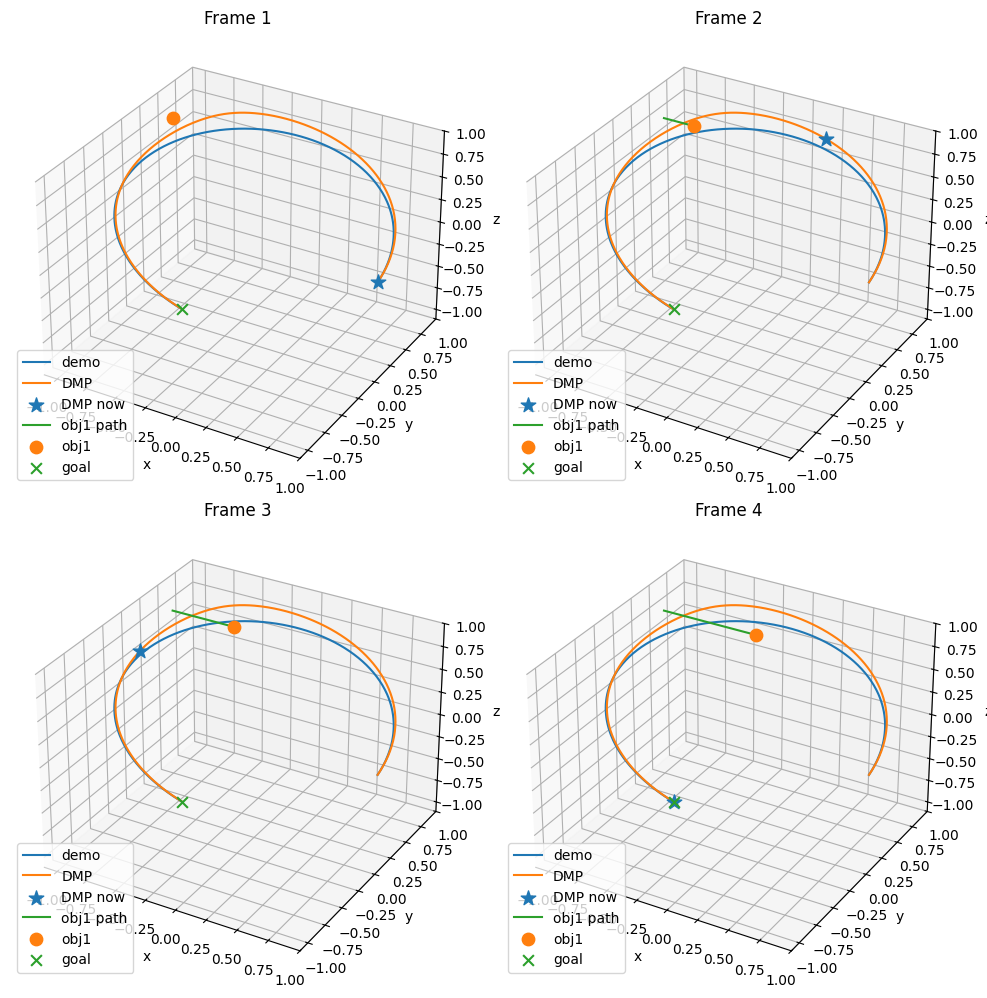

In [ ]:
import numpy as np


def gen_3d_discrete_demo(dt=0.005, tau=2.0, Axy=1.0, z_amp=0.6):
    T = int(np.round(tau / dt))
    t = np.linspace(0, tau, T)

    u = t / tau

    x = Axy * np.cos(1.5*np.pi*u)
    y = Axy * np.sin(1.5*np.pi*u)
    z = z_amp * np.sin(np.pi*u)

    pos = np.vstack([x, y, z])
    return pos, t

dt = 0.005
pos, t_demo = gen_3d_discrete_demo(dt=dt, tau=2.0, Axy=1.0, z_amp=0.6)

speed = 1.0
T_new = max(int(np.round(pos.shape[1] / speed)), 2)
u = np.linspace(0, 1, T_new)

mid = pos.shape[1]//2
center = pos[:, mid]

obs1 = np.zeros((3, T_new))
obs1[:, :] = (center - np.array([0.4, 0.0, 0.0])).reshape(3,1) + (np.array([0.8, 0.0, 0.0])).reshape(3,1) * u.reshape(1,-1)
obs_paths = [obs1]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_moving_OA(
    pos, dt, obs_paths, speed=speed, oa_gamma=1000, oa_beta=6.0
)
plot_dmp_4frames_moving(pos, DMP_pos, obj_paths=obs_paths, newGoal=newGoal)




## Example 2 — Helix, 2 Obstacles intersecting

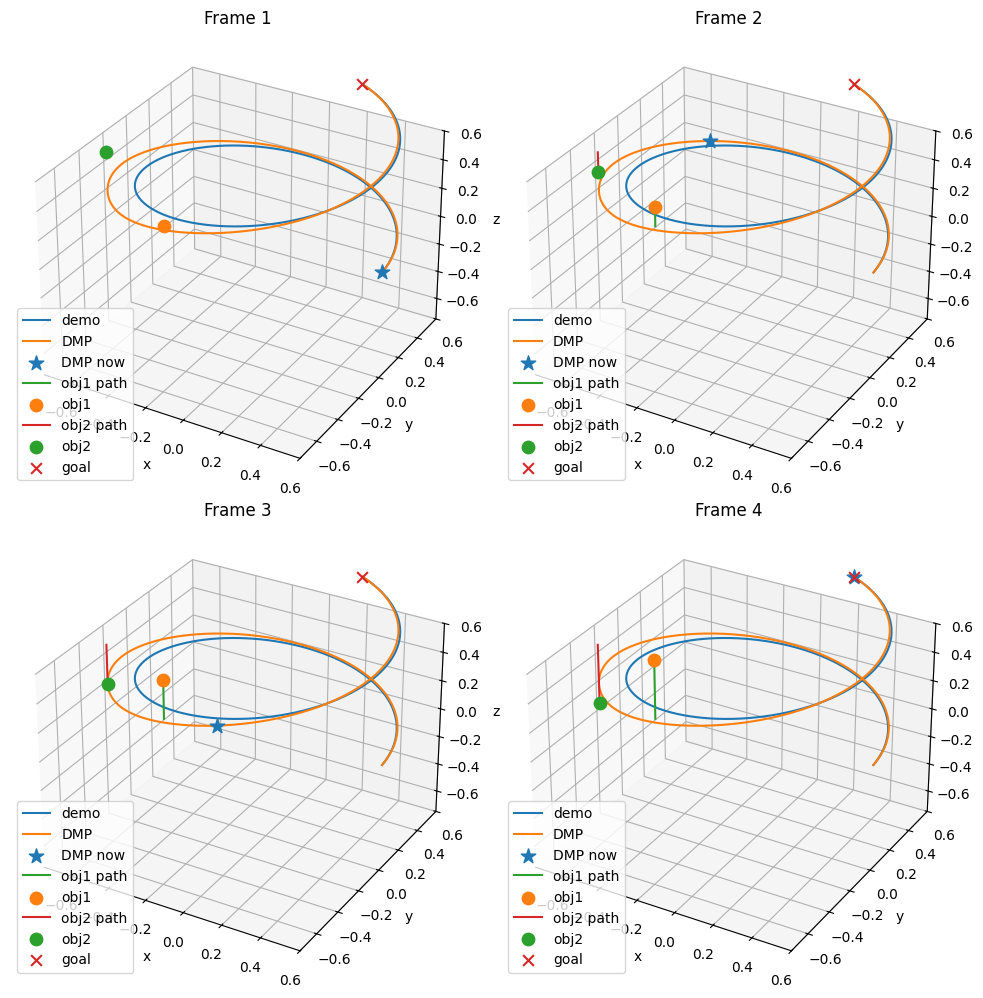

In [ ]:
def gen_helix(dt=0.005, tau=2.0, radius=0.5, z_height=1.0, turns=2.0):
    T = int(np.round(tau / dt))
    t = np.linspace(0, tau, T)
    u = t / tau

    angle = turns * 2 * np.pi * u
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    z = z_height * u

    return np.vstack([x, y, z]), t

dt = 0.005
pos, t_demo = gen_helix(dt=dt, tau=2.0, radius=0.6, z_height=0.8, turns=1.2)

speed = 1.0
T_new = max(int(np.round(pos.shape[1] / speed)), 2)
u = np.linspace(0, 1, T_new)

mid = pos.shape[1]//2
base = pos[:, mid]

obs_up = np.repeat((base + np.array([0.15, 0, -0.2])).reshape(3, 1), T_new, axis=1)
obs_up[2, :] = base[2]-0.2+0.4*u

obs_down = np.repeat((base + np.array([-0.15, 0, 0.2])).reshape(3, 1), T_new, axis=1)
obs_down[2, :] = base[2]+0.2-0.4*u

obs_paths = [obs_up, obs_down]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_moving_OA(
    pos, dt, obs_paths, speed=speed, oa_gamma=1500.0, oa_beta=6.0
)

plot_dmp_4frames_moving(pos, DMP_pos, obj_paths=obs_paths, newGoal=newGoal)



In [ ]:
from Performance_measuring import test_dmp_performance

# Example 1
dt = 0.005
pos, t_demo = gen_3d_discrete_demo(dt=dt, tau=2.0, Axy=1.0, z_amp=0.6)

speed = 1.0
T_new = max(int(np.round(pos.shape[1] / speed)), 2)
u = np.linspace(0, 1, T_new)

mid = pos.shape[1]//2
center = pos[:, mid]

obs1 = np.zeros((3, T_new))
obs1[:, :] = (center - np.array([0.4, 0.0, 0.0])).reshape(3,1) + (np.array([0.8, 0.0, 0.0])).reshape(3,1) * u.reshape(1,-1)
obs_paths = [obs1]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_moving_OA(
    pos, dt, obs_paths, speed=speed, oa_gamma=1200, oa_beta=6.0
)

_, metrics_1 = test_dmp_performance(
    pos, DMP_pos, obstacle_paths=obs_paths
)

print("\n Example 1")
for k, v in metrics_1.items():
    print(f"{k}:{v}")


# Example 2
dt = 0.005
pos, t_demo = gen_helix(dt=dt, tau=2.0, radius=0.6, z_height=0.8, turns=1.2)

speed = 1.0
T_new = max(int(np.round(pos.shape[1]/speed)), 2)
u = np.linspace(0, 1, T_new)

mid = pos.shape[1]//2
base = pos[:, mid]

obs_up = np.repeat((base + np.array([0.15, 0, -0.2])).reshape(3, 1), T_new, axis=1)
obs_up[2, :] = base[2]-0.2+0.4*u

obs_down = np.repeat((base + np.array([-0.15, 0, 0.2])).reshape(3, 1), T_new, axis=1)
obs_down[2, :] = base[2]+0.2-0.4*u

obs_paths = [obs_up, obs_down]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_moving_OA(
    pos, dt, obs_paths, speed=speed, oa_gamma=1500.0, oa_beta=6.0
)

_, metrics_2 = test_dmp_performance(
    pos, DMP_pos, obstacle_paths=obs_paths
)

print("\n Example 2")
for k, v in metrics_2.items():
    print(f"{k}:{v}")



 Example 1
final_goal_error: 0.0016333626728869575
RMS_tracking_error: 0.12104158616322112
min_distance_each_obstacle: [0.18335460175157325]
min_distance_overall: 0.18335460175157325
original_path_length: 4.8955493723507875
DMP_path_length: 5.170715018187081

 Example 2
final_goal_error: 0.0068336435707851174
RMS_tracking_error: 0.13503679480072292
min_distance_each_obstacle: [0.20822566913052667, 0.11809234220117729]
min_distance_overall: 0.11809234220117729
original_path_length: 4.59401814206933
DMP_path_length: 4.797372000457532
